# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [4]:
print("Всего текстов в датасете:", len(data))
print("\nКоличество текстов в каждой категории:")
print(data['category'].value_counts())

Всего текстов в датасете: 1986

Количество текстов в каждой категории:
category
0    999
1    987
Name: count, dtype: int64


### **2. Анализ данных**

In [5]:
# Подсказка: используйте value_counts()
counts = data['category'].value_counts()
if counts[0] > counts[1]:
    print(f"Хоккей больше: {counts[0]} текстов против {counts[1]} у космоса.")
elif counts[1] > counts[0]:
    print(f"Космос больше: {counts[1]} текстов против {counts[0]} у хоккея.")
else:
    print(f"Категории равны: по {counts[0]} текстов.")

Хоккей больше: 999 текстов против 987 у космоса.


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [6]:
import re

def clean_text(text):
    # Ваш код здесь
    # 1. Привести текст к нижнему регистру (.lower())
    text = text.lower()
    # 2. Удалить всё, кроме букв и пробелов (re.sub)
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Убрать лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    pass

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccallmksoldsegticom fred j mccall subject re vandalizing the sky articleid mksolapr organizati


### **4. Создание признаков (векторизация)**

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Ваш код здесь
# 1. Создайте CountVectorizer (остановитесь на английском)
vectorizer = CountVectorizer(stop_words='english')
# 2. Преобразуйте тексты в числа (fit_transform)
X = vectorizer.fit_transform(data['clean_text'])
# 3. Выведите сколько слов получилось
print("Количество слов в словаре:", X.sum())
print("Уникальных слов:", X.shape[1])

Количество слов в словаре: 282336
Уникальных слов: 28383


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [12]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = data['clean_text']
y = data['category']

# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 1588
Размер тестовой выборки: 398


### **6. Обучение модели**

In [15]:
from sklearn.linear_model import LogisticRegression

vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 1. Создайте модель логистической регрессии
model = LogisticRegression(max_iter=1000, random_state=42)
# 2. Обучите её на обучающих данных
model.fit(X_train_vec, y_train)
# 3. Сделайте предсказания для тестовых данных
y_pred = model.predict(X_test_vec)

print("Первые 10 предсказаний:", y_pred[:10])
print("Первые 10 реальных значений:", y_test.values[:10])

Первые 10 предсказаний: [0 0 0 1 1 1 1 0 0 0]
Первые 10 реальных значений: [0 0 0 1 1 1 1 0 0 0]


### **7. Оценка модели**

In [16]:
from sklearn.metrics import accuracy_score

# 1. Вычислите accuracy (точность) модели
accuracy = accuracy_score(y_test, y_pred)
# 2. Выведите результат в процентах
print(f"Точность модели: {accuracy:.2%}")
print(f"Точность модели: {accuracy:.4f} (в долях)")

Точность модели: 99.50%
Точность модели: 0.9950 (в долях)


**Вопрос:** Какая точность у вашей модели? Что это значит?

### **8. Анализ ошибок**

Матрица ошибок:
[[200   0]
 [  2 196]]


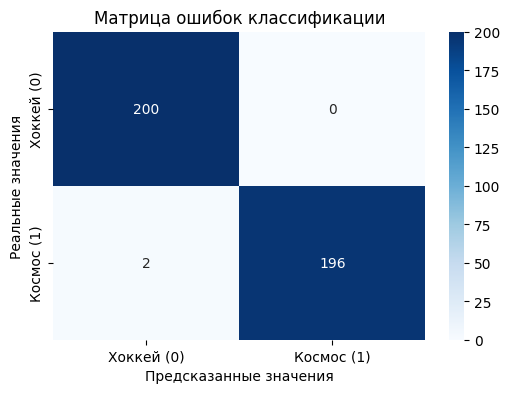

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ваш код здесь
# 1. Создайте матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

# 2. Выведите её
print("Матрица ошибок:")
print(cm)

# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Хоккей (0)', 'Космос (1)'],
            yticklabels=['Хоккей (0)', 'Космос (1)'])
plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Матрица ошибок классификации')
plt.show()
# Ваш код для визуализации здесь
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

In [19]:
space_instead_hockey = cm[1, 0]

print(f"Текстов про космос, ошибочно принятых за хоккей: {space_instead_hockey}")

Текстов про космос, ошибочно принятых за хоккей: 2
